# Tensorflow
Dataset : ReviewTokoBaju.csv

In [1]:
!pip install keras-tuner --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc
import keras_tuner as kt
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
url = "https://raw.githubusercontent.com/farrelrassya/teachingMLDL/main/02.%20Deep%20Learning/07.%20Week%207/Datasets/ReviewTokoBaju.csv"
df = pd.read_csv(url)

In [5]:
print(df.columns)


Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')


print(df.columns)


In [6]:
# Isi NaN di kolom 'Review Text' dengan string kosong
df['Review Text'] = df['Review Text'].fillna("")

# Preprocessing teks
stop_words = set(stopwords.words('indonesian'))
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    return ' '.join([word for word in text.split() if word not in stop_words])
df['clean_review'] = df['Review Text'].apply(clean_text)

# Gunakan 'Recommended IND' sebagai label
df['label'] = df['Recommended IND']


In [7]:
# Tokenisasi
tokenizer = keras.preprocessing.text.Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_review'])
sequences = tokenizer.texts_to_sequences(df['clean_review'])

# Padding
maxlen = 100
padded = keras.preprocessing.sequence.pad_sequences(sequences, maxlen=maxlen, padding='post')

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    padded,
    df['label'].values,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

In [14]:
# Model Builder dengan LSTM dan Bidirectional
def model_builder(hp):
    model = keras.Sequential()
    model.add(layers.Embedding(
        input_dim=len(tokenizer.word_index)+1,
        output_dim=hp.Choice('embedding_dim', [64, 128, 256]),
        input_length=maxlen))

    for i in range(hp.Int('rnn_layers', 1, 3)):
        model.add(layers.Bidirectional(
            layers.LSTM(units=hp.Int(f'units_{i}', 64, 256, step=64),
                        return_sequences=(i < hp.Int('rnn_layers', 1, 3)-1))
        ))

    model.add(layers.Dense(units=hp.Int('dense_units', 64, 256, step=64), activation='relu'))
    model.add(layers.Dropout(hp.Float('dropout', 0.3, 0.6, step=0.1)))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('lr', [1e-3, 1e-4])
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [15]:
# Hyperparameter Tuning
tuner = kt.RandomSearch(
    model_builder,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    overwrite=True,
    directory='my_dir',
    project_name='deep_rnn_review_fix'
)

tuner.search(X_train, y_train, epochs=10, validation_split=0.2, verbose=1)
best_model = tuner.get_best_models(num_models=1)[0]

# Training ulang model terbaik
history = best_model.fit(X_train, y_train, epochs=20, batch_size=32,
                         validation_data=(X_test, y_test),
                         callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)])


Trial 10 Complete [00h 06m 26s]
val_accuracy: 0.896753579378128

Best val_accuracy So Far: 0.9020755887031555
Total elapsed time: 01h 03m 27s
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 36 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


588/588 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9089 - loss: 0.2243 - val_accuracy: 0.8787 - val_loss: 0.2974
Epoch 2/20
588/588 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.9350 - loss: 0.1723 - val_accuracy: 0.8974 - val_loss: 0.2823
Epoch 3/20
588/588 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.9540 - loss: 0.1262 - val_accuracy: 0.8748 - val_loss: 0.3101
Epoch 4/20
588/588 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.9618 - loss: 0.1054 - val_accuracy: 0.8863 - val_loss: 0.3331
Epoch 5/20
588/588 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.9708 - loss: 0.0857 - val_accuracy: 0.8857 - val_loss: 0.4004


Akurasi Training Set: 96.09%
Akurasi Testing Set : 89.74%
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step

Classification Report:
               precision    recall  f1-score   support

           0     0.7160    0.7006    0.7082       835
           1     0.9356    0.9399    0.9378      3863

    accuracy                         0.8974      4698
   macro avg     0.8258    0.8203    0.8230      4698
weighted avg     0.8966    0.8974    0.8970      4698

AUC Score: 0.9235296944294171


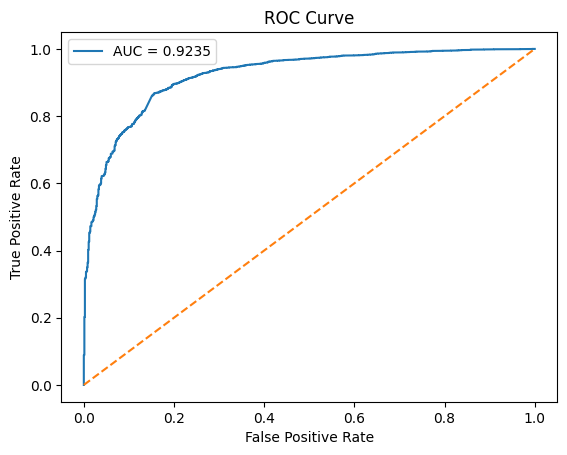

In [16]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Akurasi Training dan Testing
train_loss, train_acc = best_model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)

print(f"Akurasi Training Set: {train_acc * 100:.2f}%")
print(f"Akurasi Testing Set : {test_acc * 100:.2f}%")

# Prediksi Probabilitas & Label
y_pred_prob = best_model.predict(X_test).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Classification metrics
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
print("AUC Score:", roc_auc_score(y_test, y_pred_prob))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


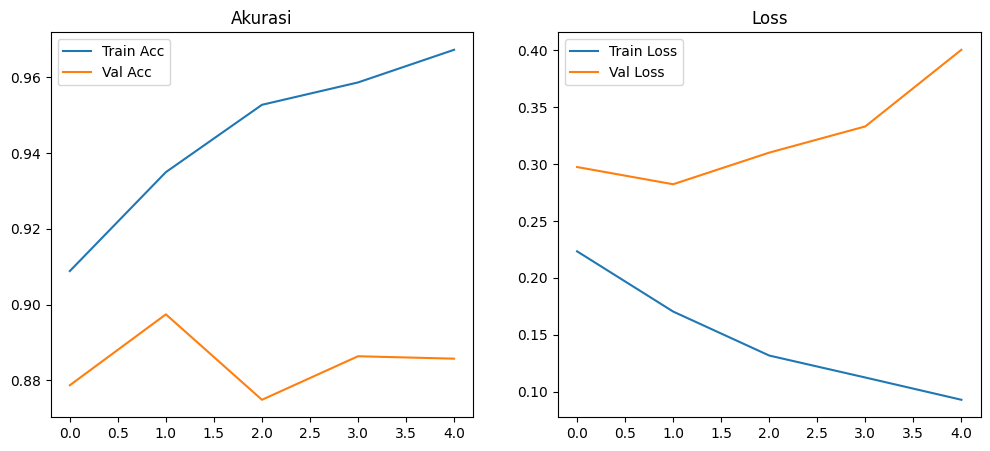

In [17]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Akurasi')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()
